# Gaussian toy example: problem setup

Creates the Gaussian toy inverse problem used in the ShuffleFlow experiments and saves it to disk:

- a $32\times32$ MNIST digit as ground truth $\mathbf{x}$,
- a random dense linear forward operator $\mathbf{A}$ with i.i.d. Gaussian measurement noise,
- a Gaussian prior fitted to the MNIST digits of one class,
- the resulting Gaussian posterior in closed form.

Inference (training the flow) lives in `gaussian_toy_example_new.ipynb`, which can load the `.pth` file written at the end of this notebook.

In [1]:
import os
import sys

sys.path.append('..')

import hydra
import numpy as np
import torch
import torchvision

from matplotlib import pyplot as plt
from matplotlib.colors import Normalize
from torch.utils.data import DataLoader

from utils.torch import *

In [2]:
FONT_WEIGHT = 'semibold'
CMAP_IMG = 'gray'
FIGURE_PATH = '../figures/gaussian_digit/'
TOY_EXAMPLE_PATH = '../data/gaussian_toy/'
TOY_EXAMPLE_FILE = os.path.join(TOY_EXAMPLE_PATH, 'gaussian_toy_example.pth')

cmap = CMAP_IMG
norm_img = Normalize(-1, 1)
norm_std = Normalize(0, 0.24)

plt.rcParams.update({'font.weight': FONT_WEIGHT, 'font.family': 'DejaVu Serif'})

os.makedirs(FIGURE_PATH, exist_ok=True)
os.makedirs(TOY_EXAMPLE_PATH, exist_ok=True)

In [3]:
# Fix the seed so the forward operator and the observation noise are reproducible.
SEED = 0
torch.manual_seed(SEED)

### Load configs

In [4]:
with hydra.initialize(version_base='1.3', config_path='../configs'):
    config = hydra.compose(
        config_name="variational_inference",
        overrides=[
            'result_path=../../results/',
            'data=mnist',
            'data.group=all',
        ]
    )

### Load data

In [5]:
transforms = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.Resize((32, 32))
])

In [6]:
train_set = torchvision.datasets.MNIST(root=config.data.data_path, train=True, download=True, transform=transforms)
test_set = torchvision.datasets.MNIST(root=config.data.data_path, train=False, download=True, transform=transforms)
train_loader = DataLoader(train_set, batch_size=10000, shuffle=False)
test_loader = DataLoader(test_set, batch_size=50, shuffle=False)
imgs_train, digits_train = next(iter(train_loader))
imgs, digit = next(iter(test_loader))

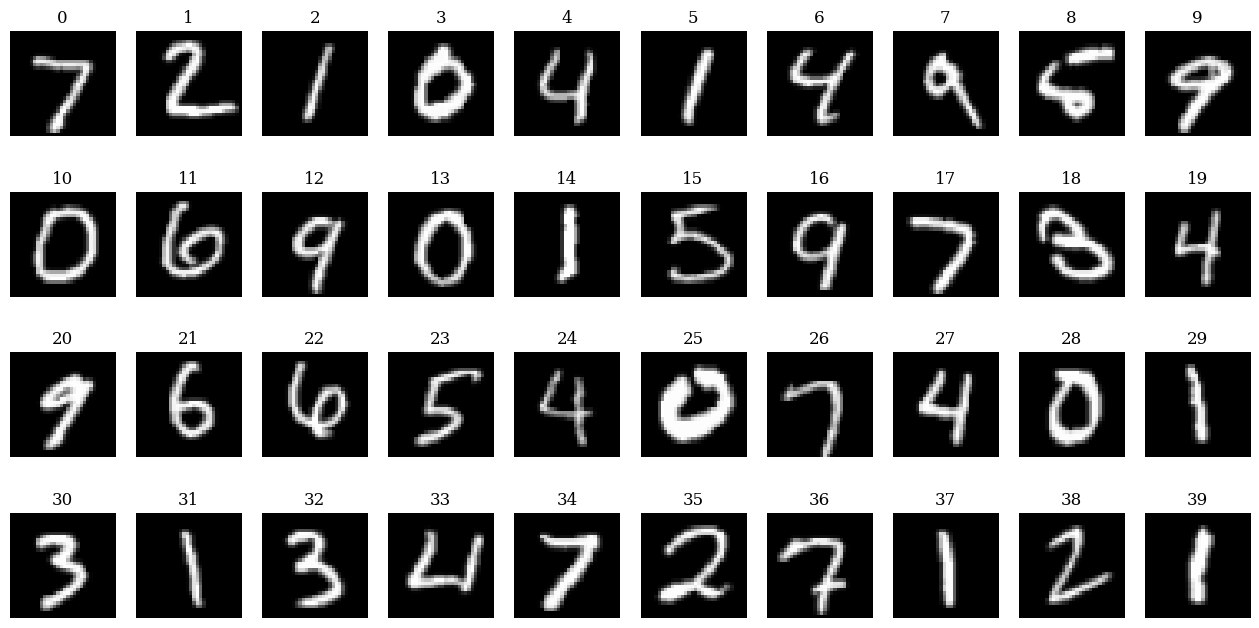

In [7]:
plt.figure(figsize=(16, 8))
for idx in range(40):
    plt.subplot(4, 10, idx + 1)
    plt.imshow(imgs[idx,0], cmap=cmap, norm=norm_img)
    plt.axis('off')
    plt.title(f'{idx}')

Pick the ground truth image (index `32` of the first test batch, a `3`).

In [8]:
GT_IDX = 32

gt = imgs[GT_IDX].squeeze(0)
N = gt.shape[0]

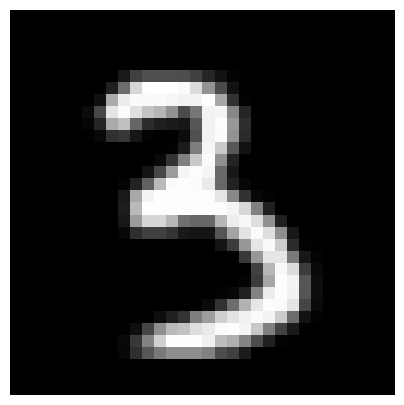

In [9]:
fig = plt.figure(figsize=(5,5))
plt.imshow(gt, cmap=cmap, norm=norm_img)
plt.axis('off')
plt.savefig(os.path.join(FIGURE_PATH, 'gt.png'), bbox_inches='tight', dpi=300)

In [10]:
coords = [torch.linspace(0, 1, steps=N), torch.linspace(0, 1, steps=N)]
XX, YY = torch.meshgrid(*coords, indexing='ij')
coords = get_mgrid(gt.shape)

### Generate observation and define likelihood

$\mathbf{y} = \mathbf{A}\mathbf{x} + \mathbf{n}$, with $\mathbf{A}\in\mathbb{R}^{M\times N^2}$ having i.i.d. $\mathcal{N}(0, 1/N^2)$ entries and $\mathbf{n}\sim\mathcal{N}(0, \sigma^2\mathbf{I})$.

In [11]:
def forward_model(x, A):
    return (x.view(-1, N**2) @ A.T).view(-1, A.shape[0])

In [12]:
N_meas = 512 # int(N**2 / 2)
A = torch.randn(N_meas, N**2) / N
noise_std = 0.1
obs = forward_model(gt, A)
obs += torch.randn_like(obs) * noise_std
cov_llh = torch.eye(N_meas) * noise_std ** 2
sigma_llh = torch.ones_like(obs) * noise_std

### Define prior

A Gaussian prior fitted to the training digits of one class: empirical mean, and a diagonal covariance built from the per-pixel variances (scaled down by 4).

In [13]:
PRIOR_DIGIT = 3

train_imgs = imgs_train[digits_train==PRIOR_DIGIT]
train_imgs += torch.randn_like(train_imgs) * 0.05
mu_prior = train_imgs.mean(0).squeeze()
cov_prior = train_imgs.reshape(-1, N**2).permute(1,0).cov(correction=0)
sigma_prior = cov_prior.diag().view(N,N).sqrt()
cov_prior = torch.diag(sigma_prior.flatten()**2) / 4

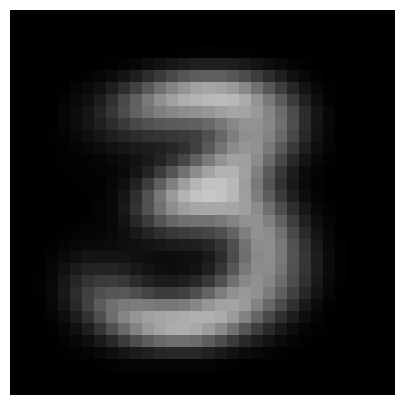

In [14]:
fig = plt.figure(figsize=(5,5))
plt.imshow(mu_prior, cmap=cmap, norm=norm_img)
plt.axis('off')
plt.savefig(os.path.join(FIGURE_PATH, 'mean_prior.png'), bbox_inches='tight', dpi=300)

(-0.5, 31.5, 31.5, -0.5)

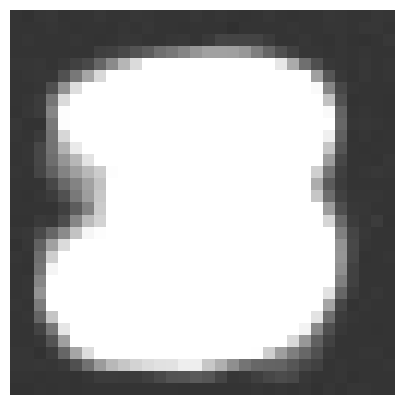

In [15]:
fig = plt.figure(figsize=(5,5))
plt.imshow(sigma_prior, cmap=cmap, norm=norm_std)
plt.axis('off')
# plt.savefig(os.path.join(FIGURE_PATH, 'std_prior.png'), bbox_inches='tight', dpi=300)

### Calculate posterior

Gaussian likelihood + Gaussian prior gives a Gaussian posterior in closed form:

$$\mathbf{\Lambda} = \mathbf{A}^\top\mathbf{\Sigma}_\text{llh}^{-1}\mathbf{A} + \mathbf{\Sigma}_\text{prior}^{-1},\qquad
\mathbf{\Sigma}_\text{pos} = \mathbf{\Lambda}^{-1},\qquad
\mathbf{\mu}_\text{pos} = \mathbf{\Sigma}_\text{pos}\left(\mathbf{A}^\top\mathbf{\Sigma}_\text{llh}^{-1}\mathbf{y} + \mathbf{\Sigma}_\text{prior}^{-1}\mathbf{\mu}_\text{prior}\right).$$

In [16]:
def get_gaussian_posterior(obs, A, cov_llh, mean_prior, cov_prior):
    Lam = A.T @ torch.inverse(cov_llh) @ A + torch.inverse(cov_prior)
    cov_pos = torch.inverse(Lam)
    mean_pos = cov_pos @ (A.T @ torch.inverse(cov_llh) @ obs.flatten() + torch.inverse(cov_prior) @ mean_prior.flatten())
    return mean_pos, cov_pos

In [17]:
mean_pos, cov_pos = get_gaussian_posterior(obs, A, cov_llh, mu_prior, cov_prior)
mean_pos = mean_pos.view(N, N)
sigma_pos = cov_pos.diag().view(N, N).sqrt()

### Visualization

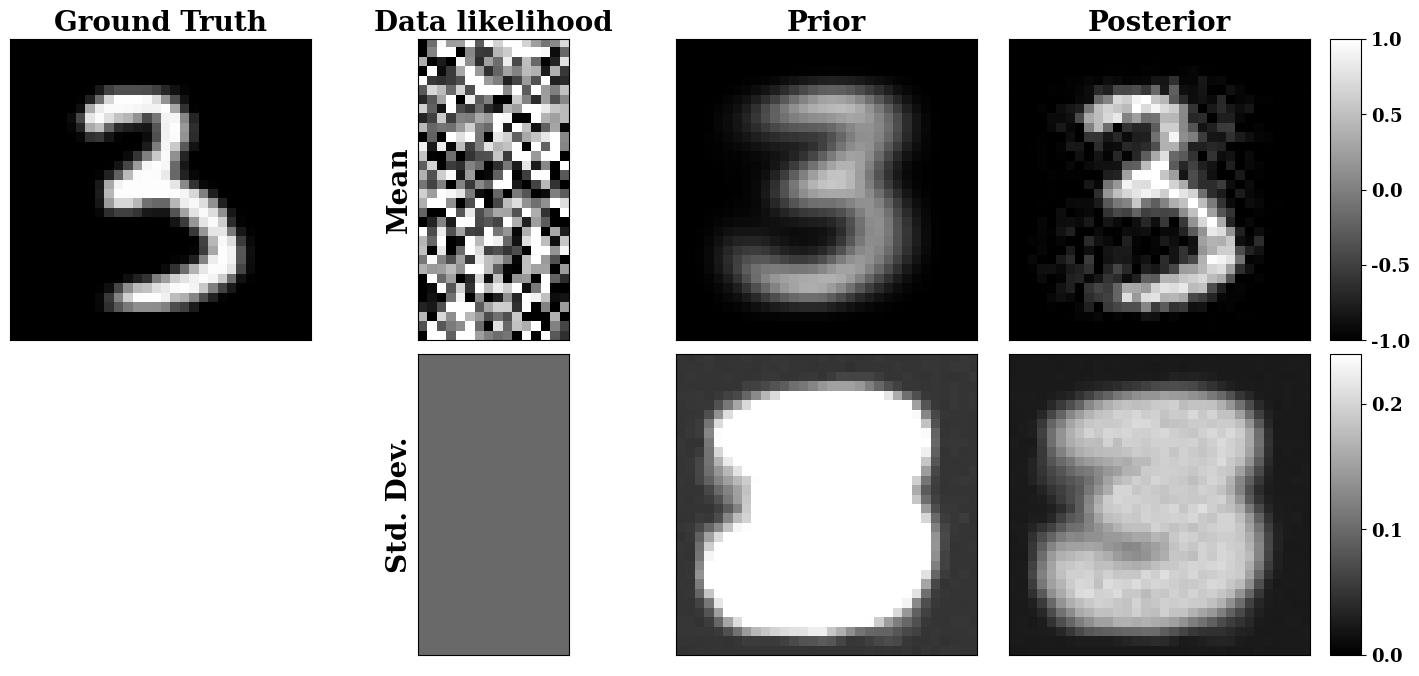

In [18]:
fig = plt.figure(figsize=(17,8))
gs = plt.GridSpec(8,16)

ax = plt.subplot(gs[0:4,0:4])
ax.imshow(gt, cmap=cmap, norm=norm_img)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Ground Truth', fontsize=20, fontweight='semibold')

# Likelihood.
ax = plt.subplot(gs[0:4,4:8])
ax.imshow(obs.view(N,N//2), cmap=cmap, norm=norm_img)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Data likelihood', fontsize=20, fontweight='semibold')
ax.set_ylabel('Mean', fontsize=20, fontweight='semibold')

ax = plt.subplot(gs[4:8,4:8])
ax.imshow(sigma_llh.view(N,N//2), cmap=cmap, norm=norm_std)
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylabel('Std. Dev.', fontsize=20, fontweight='semibold')

# Prior.
ax = plt.subplot(gs[0:4,8:12])
ax.imshow(mu_prior, cmap=cmap, norm=norm_img)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Prior', fontsize=20, fontweight='semibold')

ax = plt.subplot(gs[4:8,8:12])
ax.imshow(sigma_prior, cmap=cmap, norm=norm_std)
ax.set_xticks([])
ax.set_yticks([])

# Posterior.
ax = plt.subplot(gs[0:4,12:16])
ax.imshow(mean_pos, cmap=cmap, norm=norm_img)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Posterior', fontsize=20, fontweight='semibold')
cax = fig.add_axes([ax.get_position().x1+0.012, ax.get_position().y0, 0.018, ax.get_position().height])
cb = plt.colorbar(mappable=ax.images[0], cax=cax, norm=norm_img)
cb.set_ticks([-1.0, -0.5, 0.0, 0.5, 1.0])
cb.set_ticklabels(['-1.0', '-0.5', '0.0', '0.5', '1.0'], fontsize=13)

ax = plt.subplot(gs[4:8,12:16])
ax.imshow(sigma_pos, cmap=cmap, norm=norm_std)
ax.set_xticks([])
ax.set_yticks([])
# ax.set_title('Posterior Std. Dev.', fontsize=20, fontweight='semibold')
cax = fig.add_axes([ax.get_position().x1+0.012, ax.get_position().y0, 0.018, ax.get_position().height])
cb = plt.colorbar(mappable=ax.images[0], cax=cax, norm=norm_std)
cb.set_ticks([0.0, 0.1, 0.2])
cb.set_ticklabels(['0.0', '0.1', '0.2'], fontsize=13)

plt.savefig('../figures/figure_toy_setup.png', dpi=256, bbox_inches='tight')

### Save the toy example

Everything needed to run inference downstream: the ground truth, the forward operator, the observation, the likelihood/prior/posterior parameters, and the pixel coordinate grid.

In [19]:
toy_example = {
    'seed': SEED,
    'N': N,
    'N_meas': N_meas,
    'gt_idx': GT_IDX,
    'prior_digit': PRIOR_DIGIT,
    'gt': gt,
    'coords': coords,
    'A': A,
    'obs': obs,
    'noise_std': noise_std,
    'cov_llh': cov_llh,
    'sigma_llh': sigma_llh,
    'mu_prior': mu_prior,
    'cov_prior': cov_prior,
    'sigma_prior': sigma_prior,
    'mean_pos': mean_pos,
    'cov_pos': cov_pos,
    'sigma_pos': sigma_pos,
}
torch.save(toy_example, TOY_EXAMPLE_FILE)
print(f'Saved toy example to {TOY_EXAMPLE_FILE}')

Saved toy example to ../data/gaussian_toy/gaussian_toy_example.pth


Load it back in another notebook with:

```python
toy_example = torch.load('../data/gaussian_toy/gaussian_toy_example.pth')
gt, A, obs = toy_example['gt'], toy_example['A'], toy_example['obs']
```